In [1]:
import pandas as pd
from scipy.stats import wilcoxon
import itertools

# 讀取 Excel 檔案
file_path = r"D:\IC LAB\Gait analysis\碩論相關\實驗結果\split6-9\最終結果.xlsx"
xls = pd.ExcelFile(file_path)

# 讀取 '演算法' 工作表
df_alg = xls.parse("演算法")

# 將資料依照演算法分組
grouped = df_alg.groupby('Alg.')

# 建立兩個字典：儲存 Cluster 0 / Cluster 1 的準確率資料
cluster0_data = {name: group['Cluster 0_ACC'].values for name, group in grouped}
cluster1_data = {name: group['Cluster 1_ACC'].values for name, group in grouped}

# 列出所有模型的兩兩組合
algorithms = list(cluster0_data.keys())
pairs = list(itertools.combinations(algorithms, 2))

# Wilcoxon signed-rank 檢定
results_cluster0 = []
results_cluster1 = []

for a, b in pairs:
    stat0, pval0 = wilcoxon(cluster0_data[a], cluster0_data[b])
    stat1, pval1 = wilcoxon(cluster1_data[a], cluster1_data[b])
    
    results_cluster0.append({
        'Model A': a,
        'Model B': b,
        'Wilcoxon Statistic': stat0,
        'p-value': pval0
    })
    
    results_cluster1.append({
        'Model A': a,
        'Model B': b,
        'Wilcoxon Statistic': stat1,
        'p-value': pval1
    })

# 轉為 DataFrame 方便觀察或存成 CSV
df_cluster0 = pd.DataFrame(results_cluster0)
df_cluster1 = pd.DataFrame(results_cluster1)

# 顯示結果
print("=== Cluster 0 Wilcoxon 檢定結果 ===")
print(df_cluster0)

print("\n=== Cluster 1 Wilcoxon 檢定結果 ===")
print(df_cluster1)

=== Cluster 0 Wilcoxon 檢定結果 ===
  Model A Model B  Wilcoxon Statistic   p-value
0      GA     PSO               229.5  0.951526
1      GA     SSO                41.0  0.000018
2      GA     初始解               190.5  0.775875
3     PSO     SSO                32.0  0.000060
4     PSO     初始解               194.5  0.618851
5     SSO     初始解               109.0  0.009932

=== Cluster 1 Wilcoxon 檢定結果 ===
  Model A Model B  Wilcoxon Statistic       p-value
0      GA     PSO               165.5  5.719798e-01
1      GA     SSO                38.0  4.780109e-04
2      GA     初始解                93.5  3.475156e-03
3     PSO     SSO                21.5  8.326024e-07
4     PSO     初始解                80.5  1.232104e-03
5     SSO     初始解                31.5  5.144626e-06


In [4]:
# 重新載入必要套件與資料
import pandas as pd
from scipy.stats import wilcoxon

# 重新載入檔案
file_path = r"D:\IC LAB\Gait analysis\碩論相關\實驗結果\split6-9\最終結果.xlsx"
# df = pd.read_excel(file_path, sheet_name='工作表1')
df = pd.read_excel(file_path, sheet_name='修正')
# 準備 Cluster 0 的資料
cluster0_df = df[['model', 'Cluster 0_ACC']].dropna()

# 將每組 model 的準確率整理成 dictionary
model_groups = cluster0_df.groupby('model')['Cluster 0_ACC'].apply(list).to_dict()

# 模型名稱
models = list(model_groups.keys())

# 執行 Wilcoxon 成對比較
wilcoxon_results = []
for i in range(len(models)):
    for j in range(i + 1, len(models)):
        model_a = models[i]
        model_b = models[j]
        try:
            stat, p_value = wilcoxon(model_groups[model_a], model_groups[model_b])
            wilcoxon_results.append({
                'Model A': model_a,
                'Model B': model_b,
                'Wilcoxon Statistic': stat,
                'p-value': p_value
            })
        except ValueError as e:
            wilcoxon_results.append({
                'Model A': model_a,
                'Model B': model_b,
                'Wilcoxon Statistic': None,
                'p-value': None,
                'Error': str(e)
            })

# 整理成表格並顯示
wilcoxon_df = pd.DataFrame(wilcoxon_results)
print(wilcoxon_df)

        Model A       Model B  Wilcoxon Statistic       p-value
0   SSO-ST-GCN*  SSO-ST-GCN++               176.5  3.751530e-01
1   SSO-ST-GCN*       ST-GCN*                 0.0  2.556187e-06
2   SSO-ST-GCN*      ST-GCN++                 0.0  1.862645e-09
3  SSO-ST-GCN++       ST-GCN*                 0.0  1.862645e-09
4  SSO-ST-GCN++      ST-GCN++                 2.0  5.587935e-09
5       ST-GCN*      ST-GCN++               113.0  1.283373e-02


In [8]:
# 重新載入必要套件與資料
import pandas as pd
from scipy.stats import wilcoxon

# 重新載入檔案
file_path = r"D:\IC LAB\Gait analysis\碩論相關\實驗結果\split6-9\最終結果.xlsx"
# df = pd.read_excel(file_path, sheet_name='工作表1')
df = pd.read_excel(file_path, sheet_name='修正')
# 準備 Cluster 0 的資料
cluster0_df = df[['model', 'Cluster 1_ACC']].dropna()

# 將每組 model 的準確率整理成 dictionary
model_groups = cluster0_df.groupby('model')['Cluster 1_ACC'].apply(list).to_dict()

# 模型名稱
models = list(model_groups.keys())

# 執行 Wilcoxon 成對比較
wilcoxon_results = []
for i in range(len(models)):
    for j in range(i + 1, len(models)):
        model_a = models[i]
        model_b = models[j]
        try:
            stat, p_value = wilcoxon(model_groups[model_a], model_groups[model_b])
            wilcoxon_results.append({
                'Model A': model_a,
                'Model B': model_b,
                'Wilcoxon Statistic': stat,
                'p-value': p_value
            })
        except ValueError as e:
            wilcoxon_results.append({
                'Model A': model_a,
                'Model B': model_b,
                'Wilcoxon Statistic': None,
                'p-value': None,
                'Error': str(e)
            })

# 整理成表格並顯示
wilcoxon_df = pd.DataFrame(wilcoxon_results)
print(wilcoxon_df)

        Model A       Model B  Wilcoxon Statistic       p-value
0   SSO-ST-GCN*  SSO-ST-GCN++                16.0  3.147870e-07
1   SSO-ST-GCN*       ST-GCN*                 1.0  3.725290e-09
2   SSO-ST-GCN*      ST-GCN++                 0.0  1.862645e-09
3  SSO-ST-GCN++       ST-GCN*                88.0  2.187775e-03
4  SSO-ST-GCN++      ST-GCN++                 5.0  1.862645e-08
5       ST-GCN*      ST-GCN++                68.0  3.800932e-04


In [9]:
summary_stats = {
    model: {
        'mean': round(pd.Series(scores).mean(), 6),
        'median': round(pd.Series(scores).median(), 6)
    }
    for model, scores in model_groups.items()
}

# 整理成 DataFrame 顯示
summary_df = pd.DataFrame.from_dict(summary_stats, orient='index').reset_index()
summary_df.columns = ['Model', 'Mean Accuracy', 'Median Accuracy']
print(summary_df)

          Model  Mean Accuracy  Median Accuracy
0   SSO-ST-GCN*       0.770347         0.770833
1  SSO-ST-GCN++       0.760370         0.761458
2       ST-GCN*       0.749954         0.749306
3      ST-GCN++       0.733495         0.739583


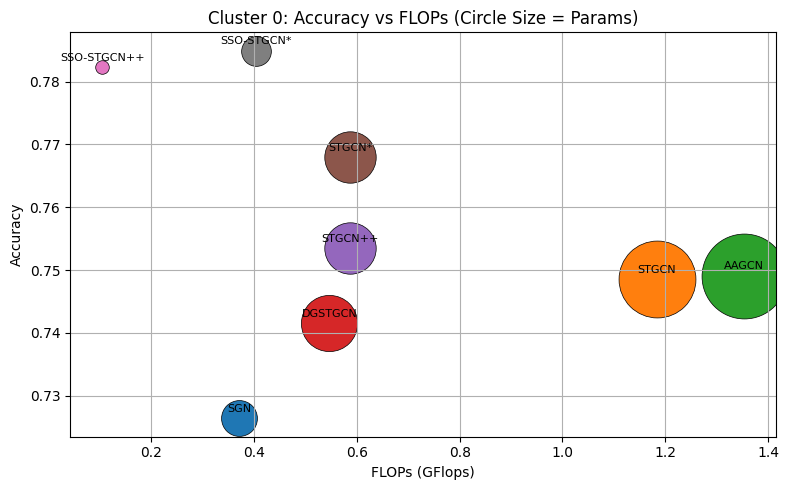

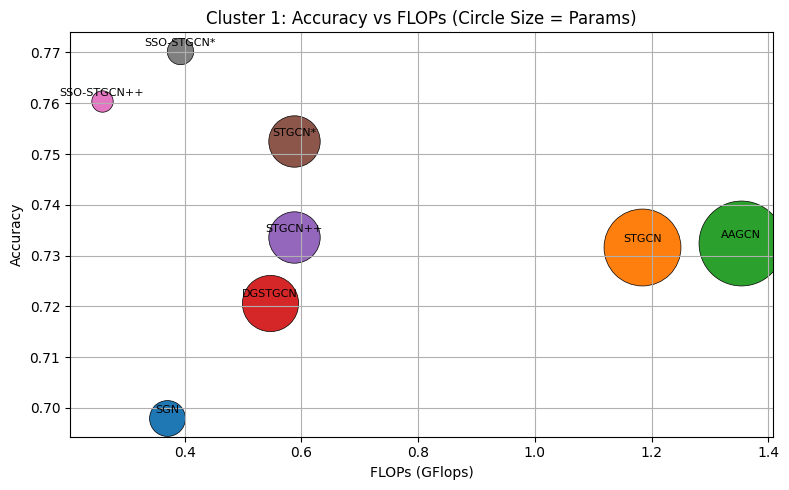

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# 建立資料
data = {
    "Model": ["SGN", "STGCN", "AAGCN", "DGSTGCN", "STGCN++", "STGCN*", "SSO-STGCN++", "SSO-STGCN*"] * 2,
    "Cluster": ["Cluster 0"] * 8 + ["Cluster 1"] * 8,
    "Accuracy": [0.726389, 0.748519, 0.749097, 0.741551, 0.753495, 0.767917, 0.782338, 0.784907,
                 0.697940, 0.731690, 0.732454, 0.720741, 0.733565, 0.752500, 0.760370, 0.770347],
    "FLOPs": [0.370462, 1.183615, 1.353584, 0.546565, 0.587210, 0.587210, 0.104258, 0.404276,
              0.370462, 1.183615, 1.353584, 0.546565, 0.587210, 0.587210, 0.258450, 0.392651],
    "Params": [0.665740, 3.065416, 3.736668, 1.637932, 1.369664, 1.369664, 0.095780, 0.457676,
               0.665740, 3.065416, 3.736668, 1.637932, 1.369664, 1.369664, 0.237436, 0.360742]
}

df = pd.DataFrame(data)

# 指定每個模型的顏色
model_colors = {
    "SGN": "tab:blue",
    "STGCN": "tab:orange",
    "AAGCN": "tab:green",
    "DGSTGCN": "tab:red",
    "STGCN++": "tab:purple",
    "STGCN*": "tab:brown",
    "SSO-STGCN++": "tab:pink",
    "SSO-STGCN*": "tab:gray"
}

# 分群資料
cluster_0 = df[df["Cluster"] == "Cluster 0"]
cluster_1 = df[df["Cluster"] == "Cluster 1"]

# 畫圖：Cluster 0（實心圓 + 彩色）
fig, ax = plt.subplots(figsize=(8, 5))
for _, row in cluster_0.iterrows():
    ax.scatter(row["FLOPs"], row["Accuracy"],
               s=row["Params"] * 1000,
               color=model_colors[row["Model"]],
               edgecolors='black',
               linewidths=0.5)
    ax.text(row["FLOPs"], row["Accuracy"] + 0.001, row["Model"], fontsize=8, ha='center')
ax.set_xlabel("FLOPs (GFlops)")
ax.set_ylabel("Accuracy")
ax.set_title("Cluster 0: Accuracy vs FLOPs (Circle Size = Params)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 畫圖：Cluster 1（實心圓 + 彩色）
fig, ax = plt.subplots(figsize=(8, 5))
for _, row in cluster_1.iterrows():
    ax.scatter(row["FLOPs"], row["Accuracy"],
               s=row["Params"] * 1000,
               color=model_colors[row["Model"]],
               edgecolors='black',
               linewidths=0.5)
    ax.text(row["FLOPs"], row["Accuracy"] + 0.001, row["Model"], fontsize=8, ha='center')
ax.set_xlabel("FLOPs (GFlops)")
ax.set_ylabel("Accuracy")
ax.set_title("Cluster 1: Accuracy vs FLOPs (Circle Size = Params)")
plt.grid(True)
plt.tight_layout()
plt.show()

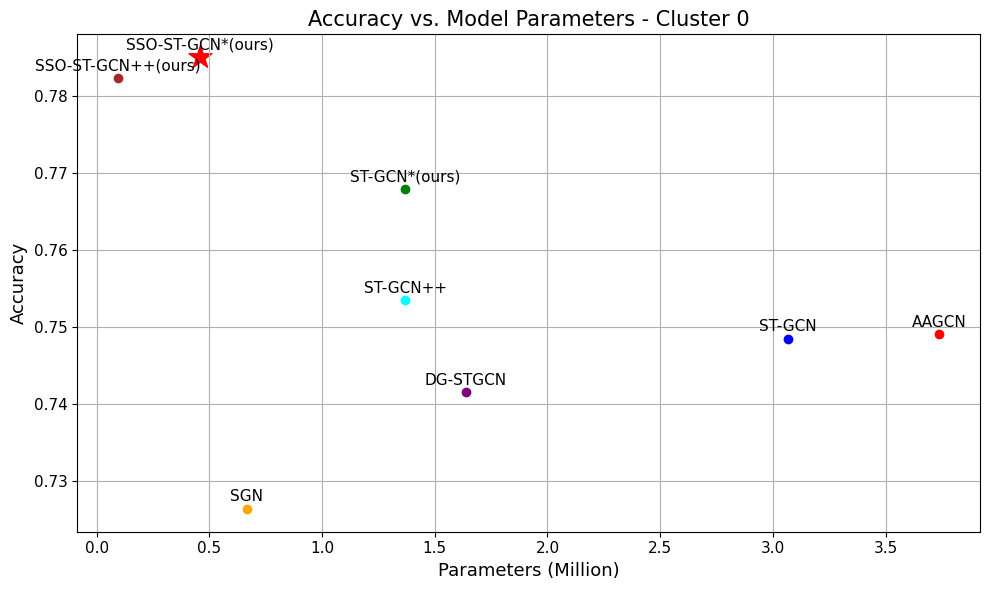

In [3]:
# 重新載入必要模組
import pandas as pd
import matplotlib.pyplot as plt

# 重新建立模型資料
model_data = {
    'Model': [
        'SGN', 'ST-GCN', 'AAGCN', 'DG-STGCN', 'ST-GCN++',
        'ST-GCN*(ours)', 'SSO-ST-GCN++(ours)', 'SSO-ST-GCN*(ours)'
    ],
    'Accuracy': [
        0.726389, 0.748519, 0.749097, 0.741551, 0.753495,
        0.767917, 0.782338, 0.785116
    ],
    'Params': [
        0.66574, 3.065416, 3.736668, 1.637932, 1.369664,
        1.369664, 0.09578, 0.457676
    ]
}

# 建立 DataFrame
plot_df = pd.DataFrame(model_data)
# 指定不同顏色以區分模型
colors = [
    'orange', 'blue', 'red', 'purple', 'cyan',
    'green', 'brown', 'black'
]

# 繪圖
plt.figure(figsize=(10, 6))
for idx, row in plot_df.iterrows():
    if row['Model'] == 'SSO-ST-GCN*(ours)':
        plt.scatter(row['Params'], row['Accuracy'], color='red', marker='*', s=300, label=row['Model'])
    else:
        plt.scatter(row['Params'], row['Accuracy'], color=colors[idx], label=row['Model'])

# 加上標籤（字體放大）
for idx, row in plot_df.iterrows():
    plt.text(row['Params'], row['Accuracy'] + 0.001, row['Model'], fontsize=11, ha='center')

# 圖表設定
plt.xlabel('Parameters (Million)', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.title('Accuracy vs. Model Parameters - Cluster 0', fontsize=15)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

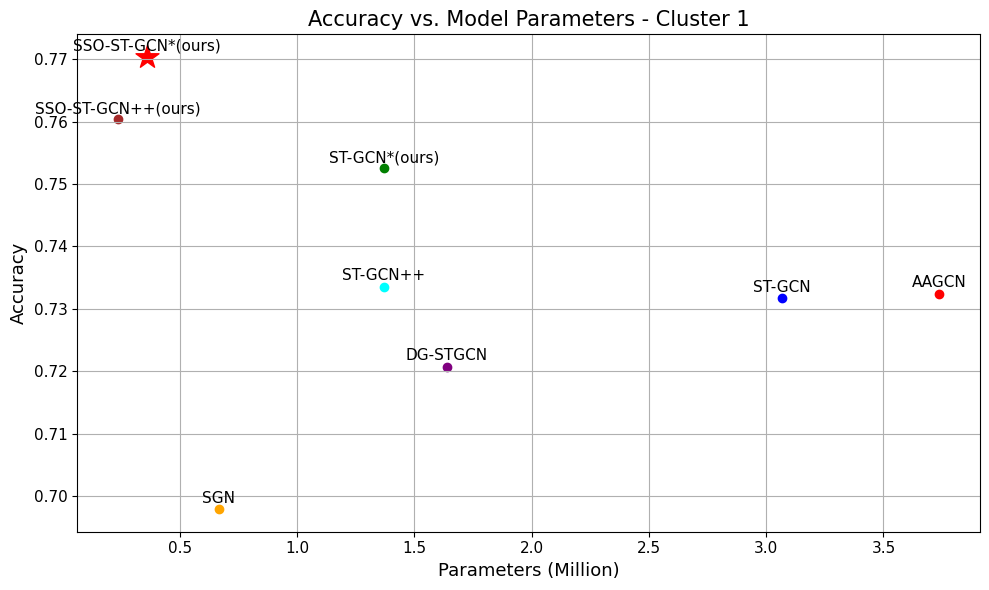

In [16]:
# 重新載入必要模組
import pandas as pd
import matplotlib.pyplot as plt

# 重新建立模型資料
model_data = {
    'Model': [
        'SGN', 'ST-GCN', 'AAGCN', 'DG-STGCN', 'ST-GCN++',
        'ST-GCN*(ours)', 'SSO-ST-GCN++(ours)', 'SSO-ST-GCN*(ours)'
    ],
    'Accuracy': [
        0.697940, 0.731690, 0.732454, 0.720741, 0.733565,
        0.752500, 0.760370, 0.770347
    ],
    'Params': [
        0.665740, 3.065416, 3.736668, 1.637932, 1.369664,
        1.369664, 0.237436, 0.360742
    ]
}

# 建立 DataFrame
plot_df = pd.DataFrame(model_data)
# 指定不同顏色以區分模型
colors = [
    'orange', 'blue', 'red', 'purple', 'cyan',
    'green', 'brown', 'black'
]

# 繪圖
plt.figure(figsize=(10, 6))
for idx, row in plot_df.iterrows():
    if row['Model'] == 'SSO-ST-GCN*(ours)':
        plt.scatter(row['Params'], row['Accuracy'], color='red', marker='*', s=300, label=row['Model'])
    else:
        plt.scatter(row['Params'], row['Accuracy'], color=colors[idx], label=row['Model'])

# 加上標籤（字體放大）
for idx, row in plot_df.iterrows():
    plt.text(row['Params'], row['Accuracy'] + 0.001, row['Model'], fontsize=11, ha='center')

# 圖表設定
plt.xlabel('Parameters (Million)', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.title('Accuracy vs. Model Parameters - Cluster 1', fontsize=15)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

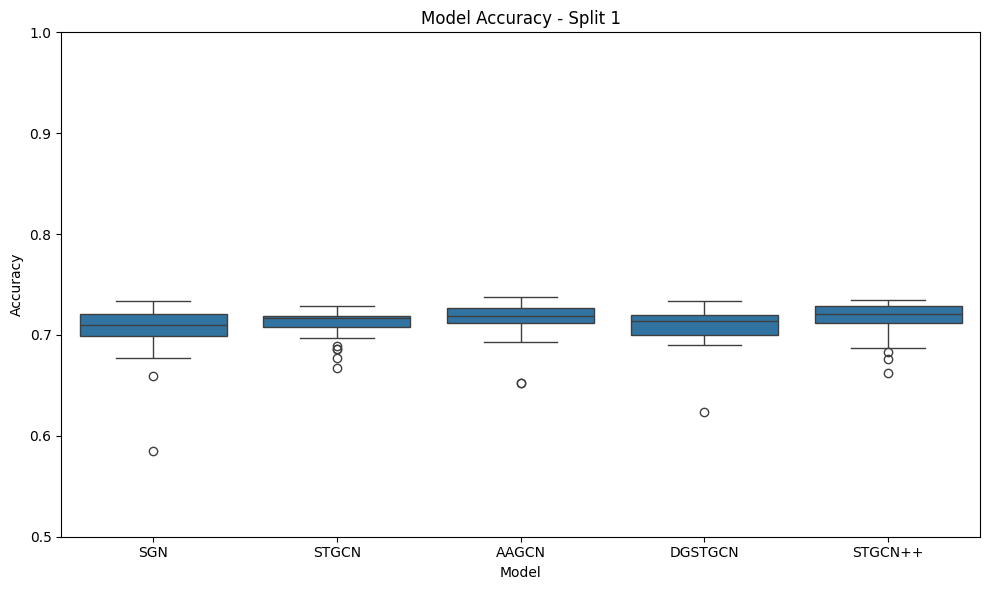

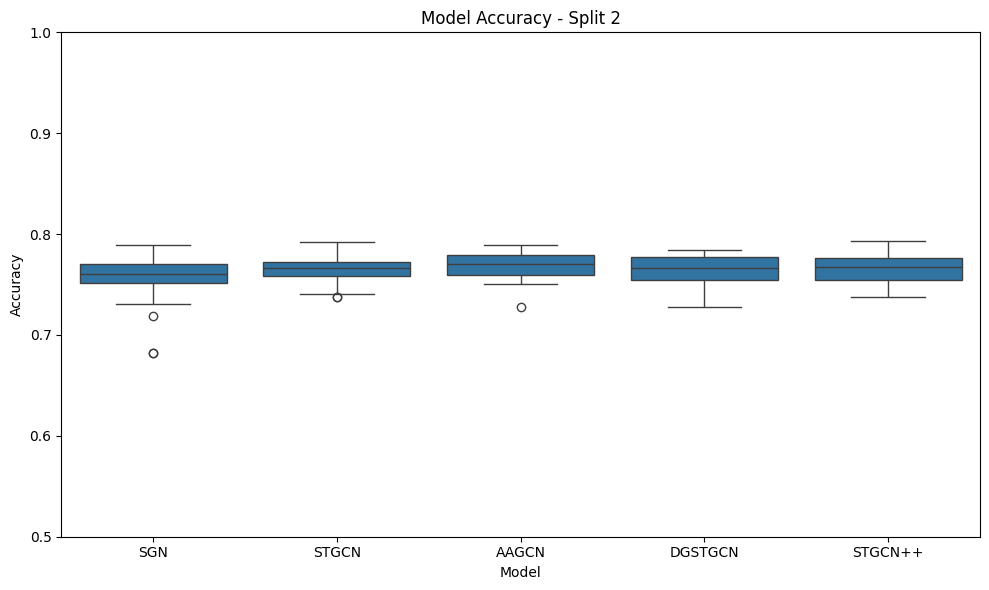

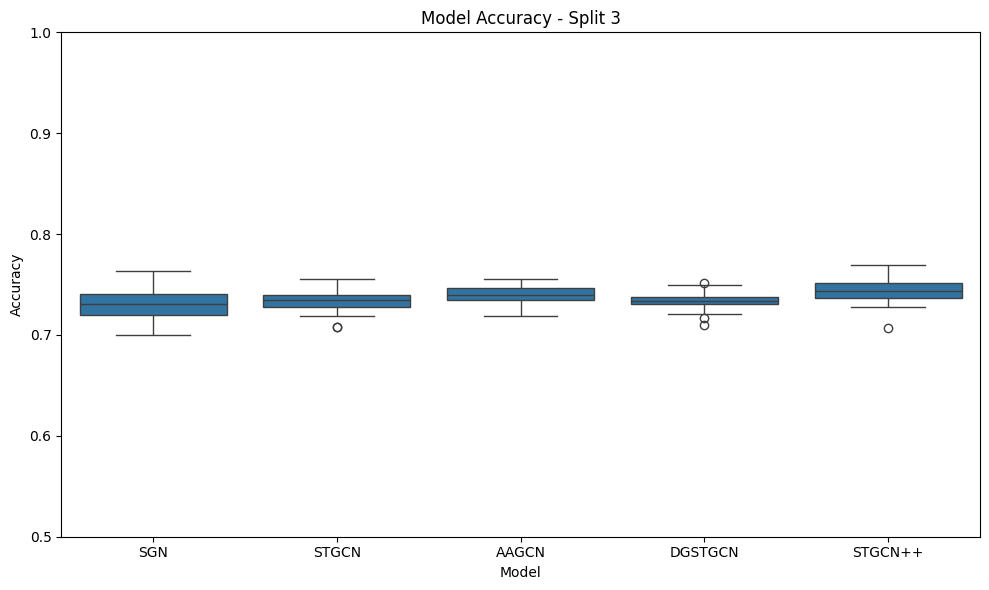

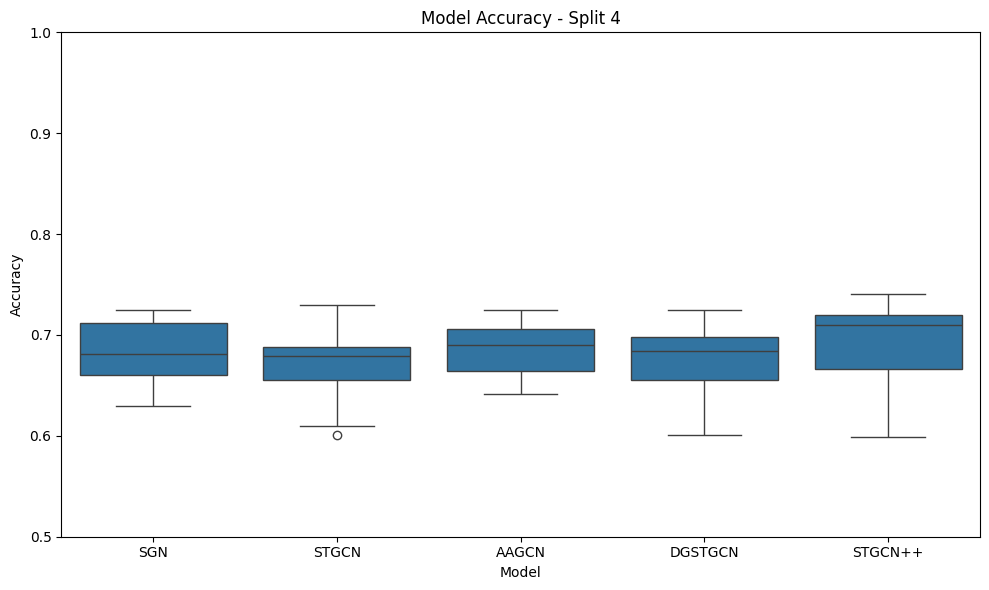

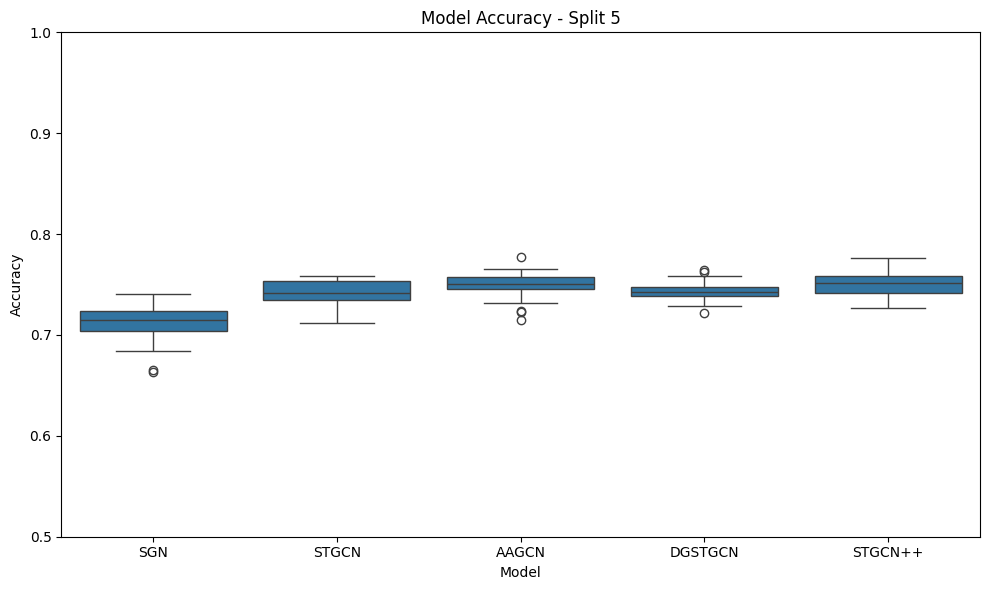

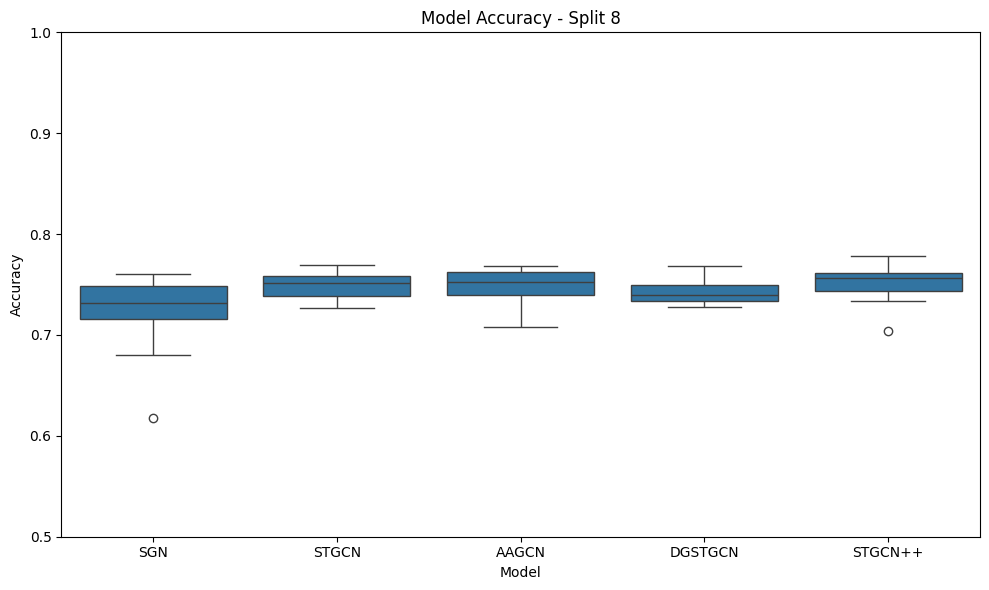

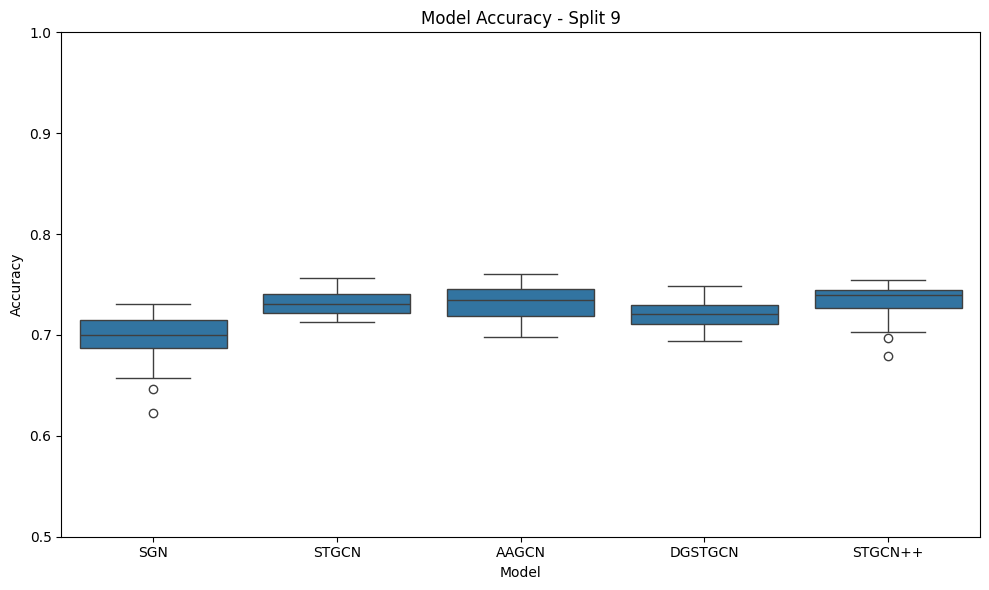

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 載入 Excel 檔案
xls = pd.ExcelFile(r"D:\IC LAB\Gait analysis\碩論相關\實驗結果\最終結果.xlsx")

# 為每個分頁繪圖
for sheet_name in xls.sheet_names:
    df = xls.parse(sheet_name)

    # 將資料轉為長格式
    df_melted = df.melt(var_name='Model', value_name='Accuracy')

    # 繪製盒鬚圖
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_melted, x='Model', y='Accuracy')
    plt.ylim(0.5, 1.0)
    plt.title(f'Model Accuracy - Split {sheet_name}')
    plt.ylabel('Accuracy')
    plt.xlabel('Model')
    plt.tight_layout()
    plt.show()


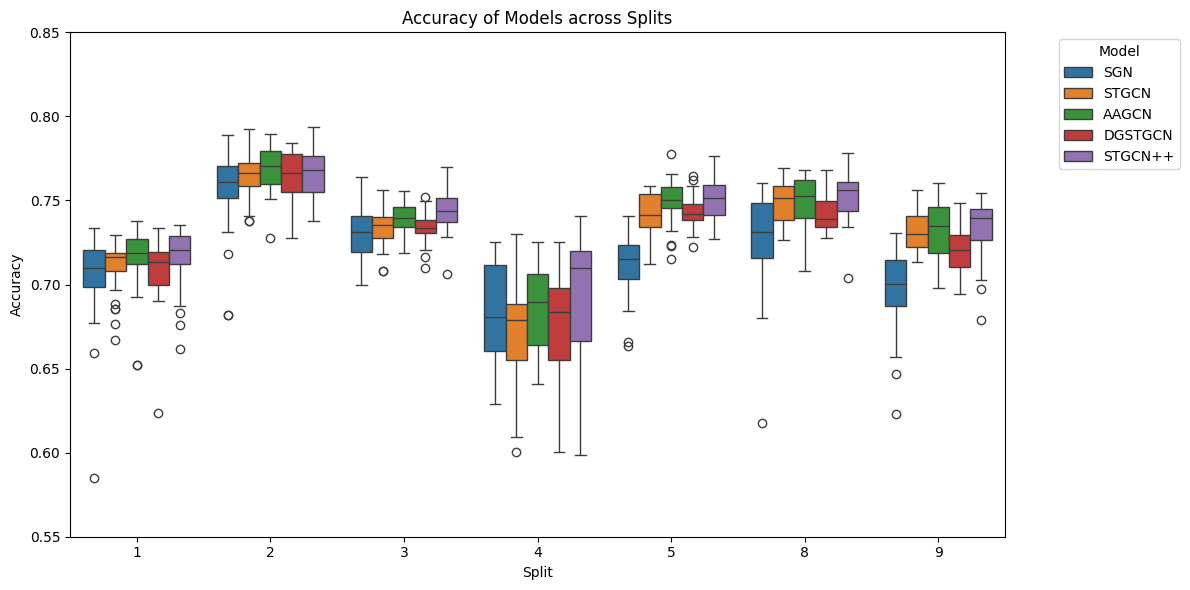

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 載入 Excel 檔案
xls = pd.ExcelFile(r"D:\IC LAB\Gait analysis\碩論相關\實驗結果\最終結果.xlsx")

# 合併所有分頁資料，加上 Split 欄位
df_all = []

for sheet_name in xls.sheet_names:
    df = xls.parse(sheet_name)
    df_melted = df.melt(var_name="Model", value_name="Accuracy")
    df_melted["Split"] = sheet_name
    df_all.append(df_melted)

# 合併成一個 DataFrame
df_all = pd.concat(df_all, ignore_index=True)

# 以 Split 為 x 軸繪製盒鬚圖，每個模型用不同顏色表示
plt.figure(figsize=(12, 6))
# sns.boxplot(data=df_all, x="Split", y="Accuracy", hue="Model", showfliers=False)
sns.boxplot(data=df_all, x="Split", y="Accuracy", hue="Model")
plt.title("Accuracy of Models across Splits")
plt.ylabel("Accuracy")
plt.xlabel("Split")
plt.ylim(0.55, 0.85)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [12]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
import pandas as pd
# 載入資料
# train = np.load(r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\data\drunk71_small\dataset_yolo_sagittal_split8_90frames_j_4class_train.npz")
# val = np.load(r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\data\drunk71_small\dataset_yolo_sagittal_split8_90frames_j_4class_val.npz")
# test = np.load(r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\data\drunk71_small\dataset_yolo_sagittal_split8_90frames_j_4class_test.npz")

# Augmentation 設定
flip_pairs = [(1, 2), (3, 4), (5, 6), (7, 8), (9, 10), (11, 12), (13, 14), (15, 16)]
augment_windows = [(0, 63), (13, 76), (26, 89)]  # 確保 64 frames 的片段

# 特徵提取函數
def extract_handcrafted_features(kp):
    kp = kp[0]  # (T, V, C)
    velocity = np.diff(kp[..., :2], axis=0)
    acceleration = np.diff(velocity, axis=0)
    vel_mean = velocity.mean(axis=0).flatten()
    acc_mean = acceleration.mean(axis=0).flatten()
    symmetry = [np.abs(kp[:, a, 0] - (1 - kp[:, b, 0])).mean() for a, b in flip_pairs]
    return np.concatenate([vel_mean, acc_mean, symmetry])

# 處理資料：augmentation + flip + 特徵
def process_data(npz_path):
    data = np.load(npz_path)
    keypoints = data["keypoints"]
    labels = data["labels"]
    names = data["names"]
    X, y = [], []

    for i in range(len(keypoints)):
        kp = keypoints[i]  # (M, T, V, C)
        label = labels[i]
        orig_T = kp.shape[1]

        # 類別0：做三段式裁剪
        if label == 0:
            for start, end in augment_windows:
                if end + 1 <= orig_T:
                    new_kp = kp[:, start:end + 1]  # (M, 64, V, C)
                    feats = extract_handcrafted_features(new_kp)
                    X.append(feats)
                    y.append(label)

        # 原始樣本
        feats = extract_handcrafted_features(kp[:, :64])  # 前64帧
        X.append(feats)
        y.append(label)

    # flip augmentation
    flipped_X, flipped_y = [], []
    for i in range(len(keypoints)):
        kp = keypoints[i][:, :64].copy()
        kp[..., 0] = 1 - kp[..., 0]
        for a, b in flip_pairs:
            kp[..., [a, b], :] = kp[..., [b, a], :]
        feats = extract_handcrafted_features(kp)
        flipped_X.append(feats)
        flipped_y.append(labels[i])

    # 合併原始與翻轉
    X.extend(flipped_X)
    y.extend(flipped_y)

    return np.array(X), np.array(y)

# 載入與處理資料
train_path = r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\data\drunk71_small\dataset_yolo_sagittal_split8_90frames_j_4class_train.npz"
val_path = r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\data\drunk71_small\dataset_yolo_sagittal_split8_90frames_j_4class_val.npz"
test_path = r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\data\drunk71_small\dataset_yolo_sagittal_split8_90frames_j_4class_test.npz"

X_train1, y_train1 = process_data(train_path)
X_val, y_val = process_data(val_path)
X_test, y_test = process_data(test_path)

X_train = np.concatenate([X_train1, X_val], axis=0)
y_train = np.concatenate([y_train1, y_val], axis=0)

# 訓練 KNN 並預測
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# 顯示分類報告
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# 報告
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.69      0.70       600
           1       0.24      0.26      0.25       240
           2       0.25      0.26      0.26       240
           3       0.34      0.33      0.33       240

    accuracy                           0.47      1320
   macro avg       0.39      0.38      0.38      1320
weighted avg       0.47      0.47      0.47      1320



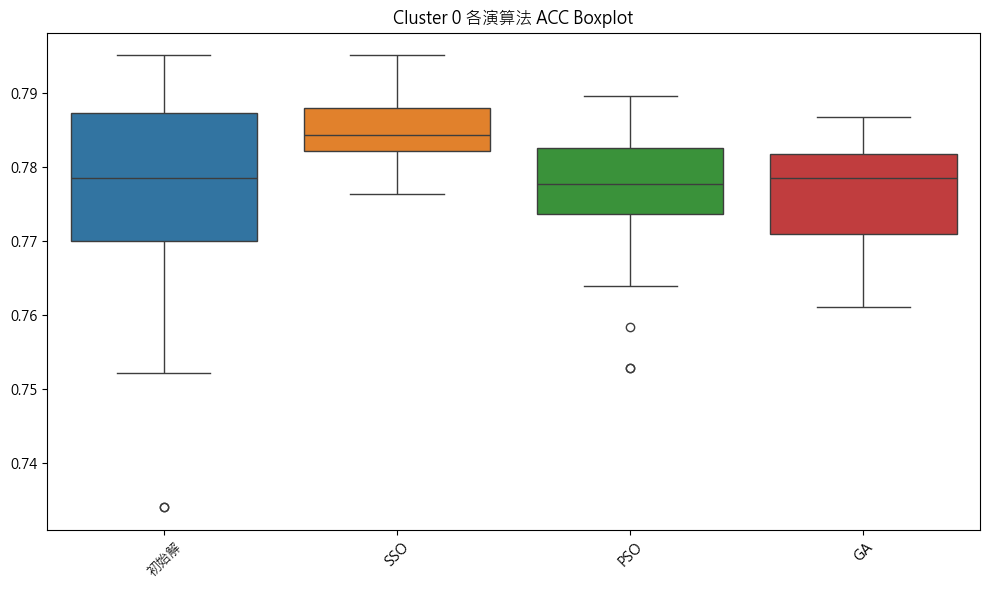

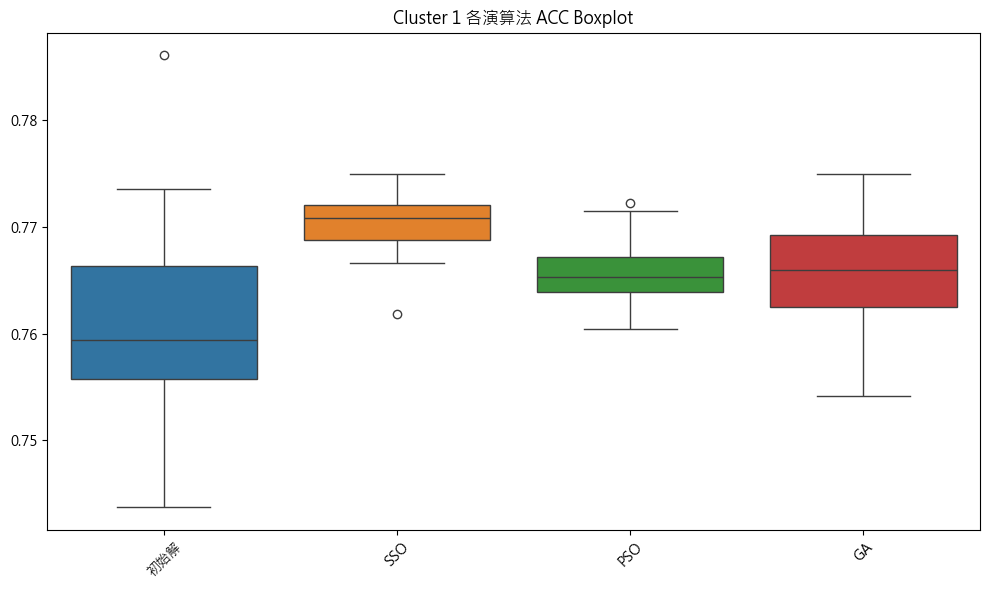

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# 設定可顯示中文的字型（依作業系統調整）
matplotlib.rcParams['font.family'] = 'Microsoft JhengHei'  # Windows 使用者
# matplotlib.rcParams['font.family'] = 'PingFang TC'  # macOS 使用者
# matplotlib.rcParams['font.family'] = 'SimHei'  # 中文 Linux 常用字型
matplotlib.rcParams['axes.unicode_minus'] = False

# 載入 Excel 檔案
file_path = r"C:\Users\User\OneDrive\桌面\claude畫圖.xlsx"  # 檔案名稱或完整路徑
xls = pd.ExcelFile(file_path)


# 讀取兩個工作表
df_cluster_0 = pd.read_excel(xls, sheet_name='Cluster 0')
df_cluster_1 = pd.read_excel(xls, sheet_name='Cluster 1')

# 繪製 Cluster 0 的 boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_cluster_0)
plt.title('Cluster 0 各演算法 ACC Boxplot')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 繪製 Cluster 1 的 boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_cluster_1)
plt.title('Cluster 1 各演算法 ACC Boxplot')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


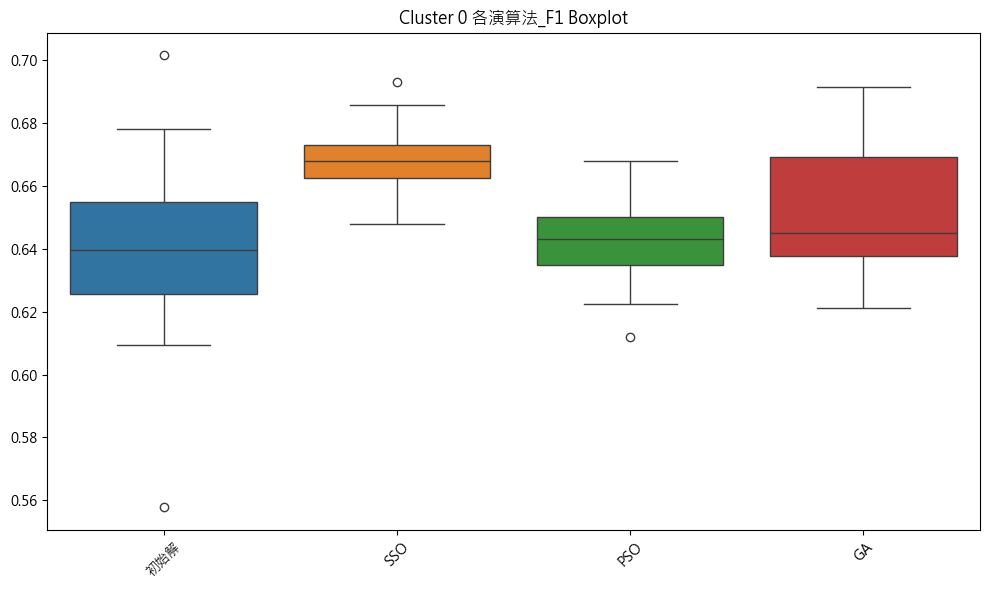

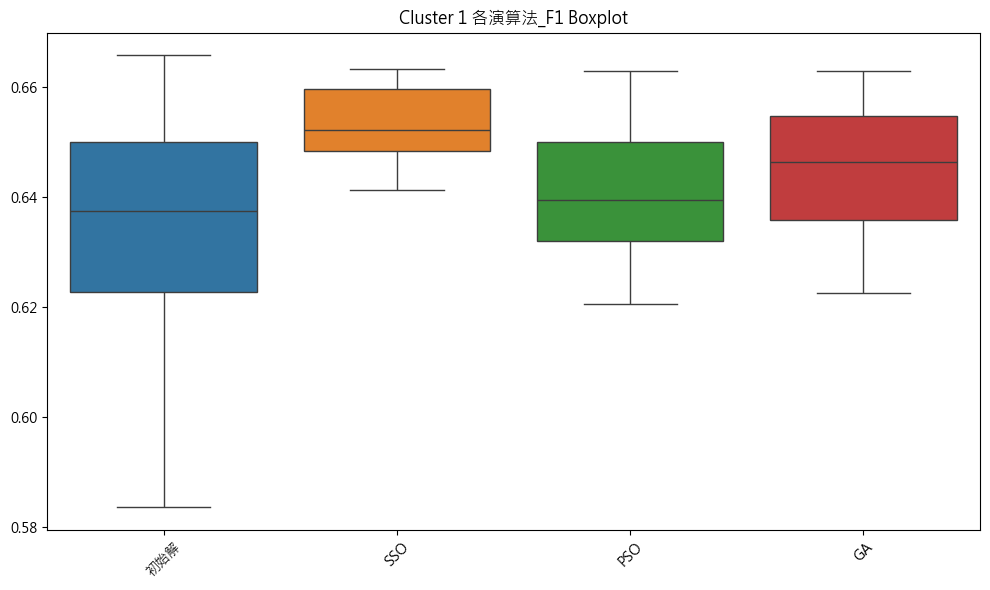

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# 設定可顯示中文的字型（依作業系統調整）
matplotlib.rcParams['font.family'] = 'Microsoft JhengHei'  # Windows 使用者
# matplotlib.rcParams['font.family'] = 'PingFang TC'  # macOS 使用者
# matplotlib.rcParams['font.family'] = 'SimHei'  # 中文 Linux 常用字型
matplotlib.rcParams['axes.unicode_minus'] = False

# 載入 Excel 檔案
file_path = r"C:\Users\User\OneDrive\桌面\claude畫圖.xlsx"  # 檔案名稱或完整路徑
xls = pd.ExcelFile(file_path)


# 讀取兩個工作表
df_cluster_0 = pd.read_excel(xls, sheet_name='Cluster 0_F1')
df_cluster_1 = pd.read_excel(xls, sheet_name='Cluster 1_F1')

# 繪製 Cluster 0 的 boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_cluster_0)
plt.title('Cluster 0 各演算法_F1 Boxplot')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 繪製 Cluster 1 的 boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_cluster_1)
plt.title('Cluster 1 各演算法_F1 Boxplot')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
